In [42]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [43]:
df = pd.read_csv("/content/Social_Network_Ads.csv")
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [44]:
df.shape

(400, 3)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [46]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [47]:
df.isnull().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


In [48]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

In [49]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Age': 0, 'EstimatedSalary': 0, 'Purchased': 0}


In [50]:
import pandas as pd

outlier_df = pd.DataFrame(list(outlier_summary.items()),
                         columns=['Column', 'Outlier_Count'])

outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

print(outlier_df)

            Column  Outlier_Count
0              Age              0
1  EstimatedSalary              0
2        Purchased              0


In [51]:
outlier_df['Percentage'] = (outlier_df['Outlier_Count'] / len(df)) * 100

print(outlier_df)

            Column  Outlier_Count  Percentage
0              Age              0         0.0
1  EstimatedSalary              0         0.0
2        Purchased              0         0.0


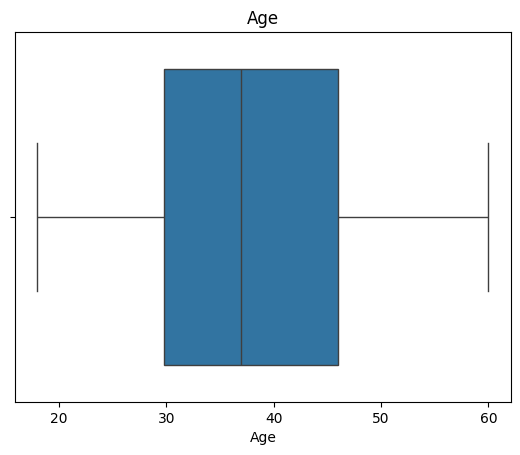

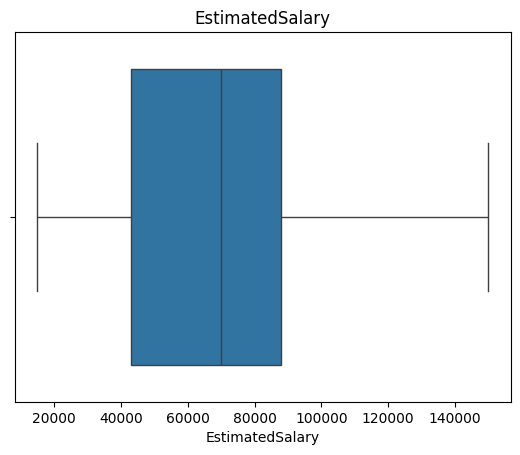

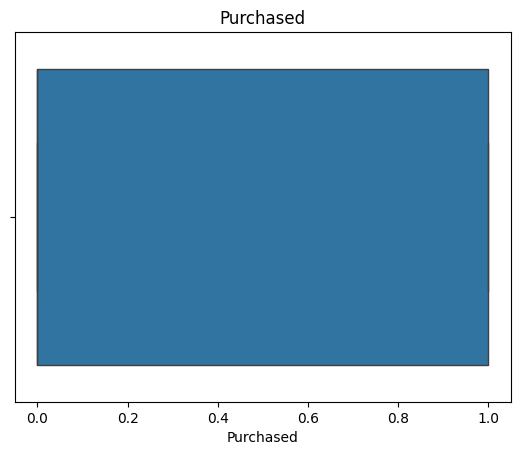

In [52]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [53]:
cols_to_cap = [
    'Age',
    'EstimatedSalary',
]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

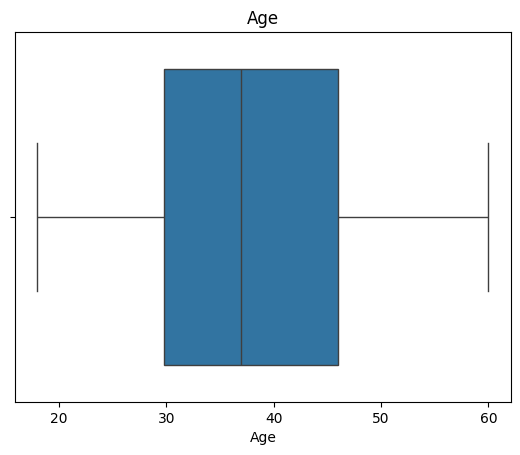

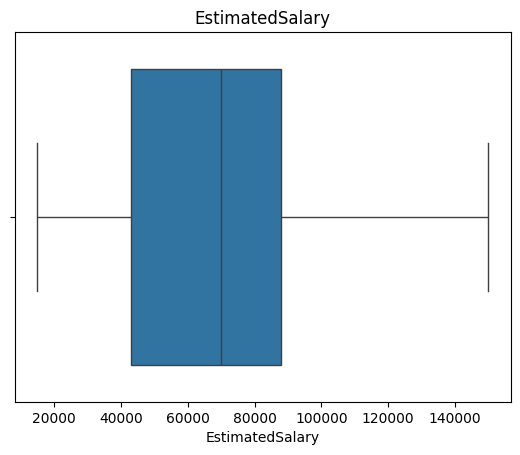

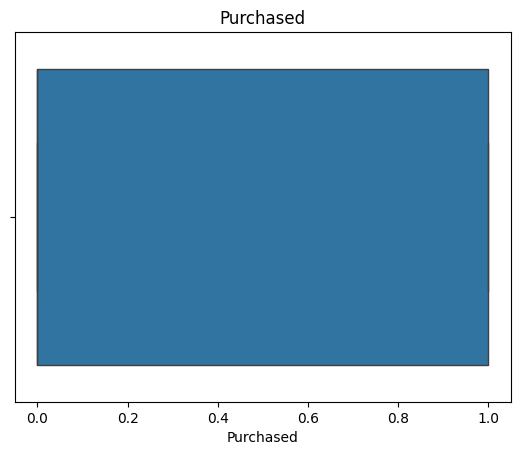

In [54]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [55]:
df["Purchased"].value_counts()

,count
Purchased,
0,257
1,143


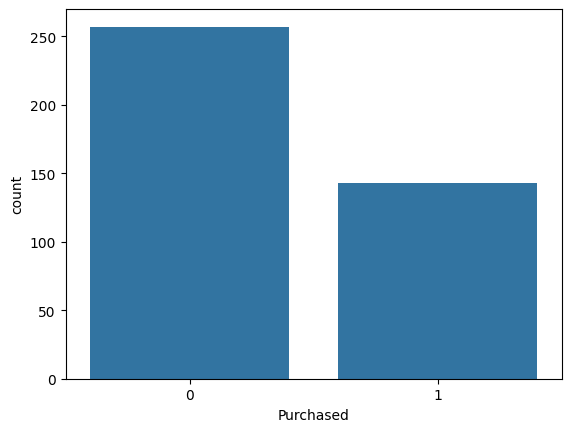

In [56]:
sns.countplot(x=df["Purchased"])
plt.show()

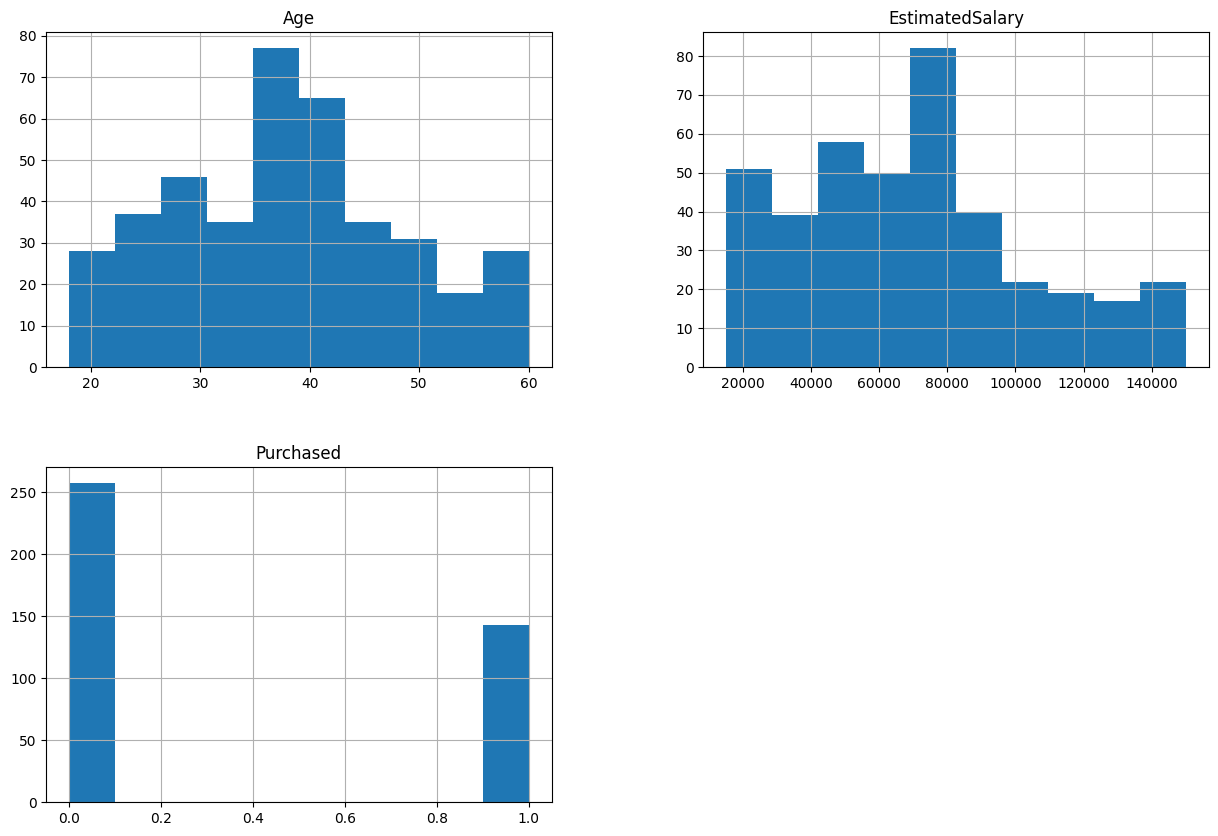

In [57]:
df.hist(figsize=(15,10))
plt.show()

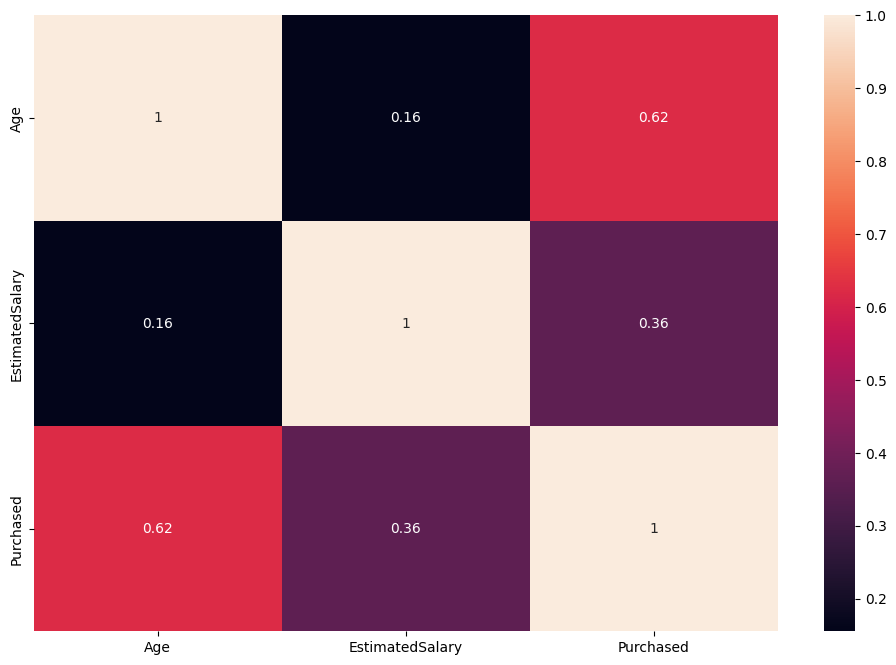

In [58]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [59]:
X = df.drop("Purchased", axis=1)

y = df["Purchased"]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [61]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [62]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [63]:
accuracy_score(y_test, y_pred_rf)

0.9

In [64]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.90      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80



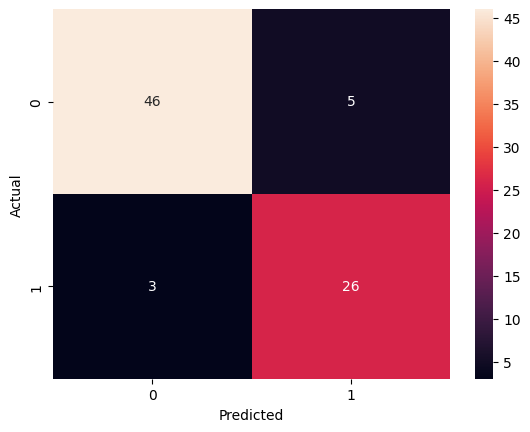

In [65]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [66]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
0,Age,0.505317
1,EstimatedSalary,0.494683


In [67]:
train_acc = rf.score(X_train, y_train)

test_acc = rf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.99375
Testing Accuracy: 0.9


In [75]:
rf.estimators_[0].get_depth()

8

In [76]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print(scores)
print(scores.mean())

[0.775  0.9375 0.925  0.8125 0.8375]
0.8575000000000002


In [77]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_pred_rf)

np.float64(0.8992562542258282)

In [78]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [79]:
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.9286680189317106


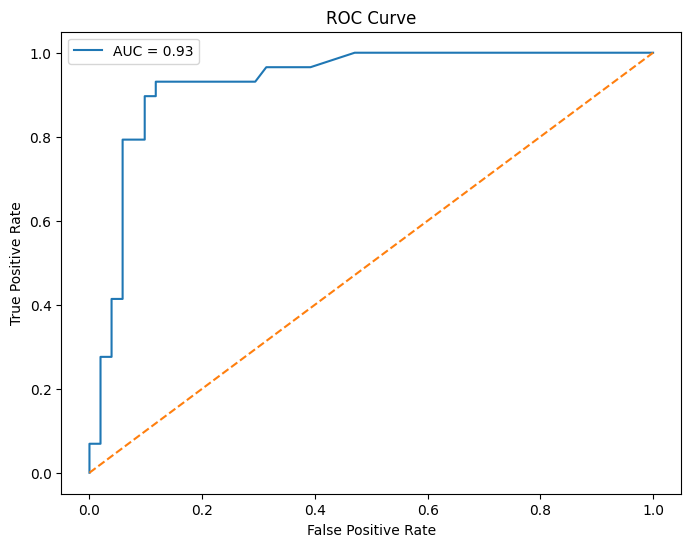

In [80]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()